# **Clasificación de péptidos antimicrobianos**

Profesor: Dr. Irvin Hussein López-Nava

Materia: Reconocimiento de Patrones

Alumna: Jazmín Alejandra Martínez Guerrero

## **Obtención de los datos**

La muestra positiva (los péptidos antimicrobianos) se obtuvieron de https://aps.unmc.edu/downloads. 
Se utilizaron los que dicen *2024 natural antimicrobial peptides (AMPs) with known activity (3306 entries)*.

La muestra negativa (los péptidos no antimibrobianos) la obtuve de https://www.uniprot.org/uniprotkb
Y filtré aquellos que tenían de 1-200 aminoácidos (180,269)


## **Lectura de los datos**


**Datos positivos**

In [1]:
# Función para leer los datos positivos

def parse_fasta_positive(file_path):
    sequences = {}
    with open(file_path, 'r') as file:
        current_id = ""
        for line in file:
            line = line.strip()
            if line.startswith(">"):
                current_id = line[1:]
                if current_id.startswith("Your search"):
                    current_id = ""
                    continue
                sequences[current_id] = ""
            elif current_id:
                sequences[current_id] += line
    return sequences

In [2]:
positives_raw = parse_fasta_positive("positive.txt")
print(type(positives_raw))
print(positives_raw)
print(len(positives_raw))

<class 'dict'>
{'AP00001': 'GLWSKIKEVGKEAAKAAAKAAGKAALGAVSEAV', 'AP00002': 'YVPLPNVPQPGRRPFPTFPGQGPFNPKIKWPQGY', 'AP00003': 'DGVKLCDVPSGTWSGHCGSSSKCSQQCKDREHFAYGGACHYQFPSVKCFCKRQC', 'AP00004': 'NLCERASLTWTGNCGNTGHCDTQCRNWESAKHGACHKRGNWKCFCYFDC', 'AP00005': 'VFIDILDKVENAIHNAAQVGIGFAKPFEKLINPK', 'AP00006': 'GNNRPVYIPQPRPPHPRI', 'AP00007': 'GNNRPVYIPQPRPPHPRL', 'AP00008': 'RLCRIVVIRVCR', 'AP00009': 'RFRPPIRRPPIRPPFYPPFRPPIRPPIFPPIRPPFRPPLGPFP', 'AP00010': 'RRIRPRPPRLPRPRPRPLPFPRPGPRPIPRPLPFPRPGPRPIPRPLPFPRPGPRPIPRPL', 'AP00011': 'WNPFKELERAGQRVRDAVISAAPAVATVGQAAAIARG', 'AP00012': 'GLFDIIKKIAESI', 'AP00013': 'GLFDIIKKIAESF', 'AP00014': 'GLLDIVKKVVGAFGSL', 'AP00015': 'GLFDIVKKVVGALGSL', 'AP00016': 'GLFDIVKKVVGAIGSL', 'AP00017': 'GLFDIVKKVVGTLAGL', 'AP00018': 'GLFDIVKKVVGAFGSL', 'AP00019': 'GLFDIAKKVIGVIGSL', 'AP00020': 'GLFDIVKKIAGHIAGSI', 'AP00021': 'GLFDIVKKIAGHIASSI', 'AP00022': 'GLFDIVKKIAGHIVSSI', 'AP00023': 'AACARFIDDFCDTLTPNIYRPRDNGQRCYAVNGHRCDFTVFNTNNGGNPIRASTPNCKTVLRTAANRCPTGGRGKIN

**Datos negativos**

In [3]:
def parse_fasta_negative(filepath):
    sequences = {}
    
    with open(filepath, 'r') as file:
        content = file.read()
        
    blocks = content.strip().split('>')
    
    for block in blocks:
        if not block:
            continue
            
        lines = block.splitlines()
        header = lines[0]
        
        seq_id = header.split('|')[1] if '|' in header else header.split()[0]
        sequence = "".join(lines[1:]).strip()
        
        if sequence:
            sequences[seq_id] = sequence
            
    return sequences

In [4]:
negatives_raw = parse_fasta_negative("negative.fasta")
print(type(negatives_raw))
print(len(negatives_raw))

<class 'dict'>
180264


## **Filtrado de datos**

Se tienen que filtrar los datos de la muestra negativa porque son muchos más (180264) que los positivos (3306), además tenemos que fijar que el número de secuencias sean parecidas entre ambas bases (sino al algoritmo podría clasificar con base a la longitud de la secuencia)

Primero debemos de asegurarnos de que los peptidos tengan toda su secuencia de aminoácidos, porque puede suceder que aparezcan X (lo cual significa que el aminoácido es desconocido) y si tenemos un aminoácido desconcido, no podemos calcular las características del péptido

In [5]:
print(len(positives_raw))
print(len(negatives_raw))

3306
180264


Tenemos 3306 datos positivos y 180264 negativos

In [6]:
def filter_canonical_peptides(peptide_dict):
    valid_aas = set("ACDEFGHIKLMNPQRSTVWY")
    return {k: v for k, v in peptide_dict.items() if set(v.upper()).issubset(valid_aas)}

positives_raw = filter_canonical_peptides(positives_raw)
negatives_raw = filter_canonical_peptides(negatives_raw)
print(len(positives_raw))
print(len(negatives_raw))

3306
179073


Tenemos 3306 datos positivos y 179073 negativos, todos con sus aminoácidos conocidos

In [7]:
# Para conocer la longitud de las secuencias de nuestras bases vamos a ver los cuartines de longitud de la cantidad de aminoacidos por peptido
import statistics

def get_peptide_length_quartiles(peptide_dict):
    lengths = [len(seq) for seq in peptide_dict.values()]
    
    if not lengths:
        return {}
        
    if len(lengths) < 4:
        raise ValueError("Insufficient data")
        
    quartiles = statistics.quantiles(lengths, n=4)

    return {
        'Q1': quartiles[0],
        'Q2': quartiles[1],
        'Q3': quartiles[2],
        'Min': min(lengths),
        'Max' : max(lengths)
    }

In [8]:
print(f"Positives {get_peptide_length_quartiles(positives_raw)}")
print(f"Negatives {get_peptide_length_quartiles(negatives_raw)}")

Positives {'Q1': 20.0, 'Q2': 29.0, 'Q3': 40.0, 'Min': 2, 'Max': 183}
Negatives {'Q1': 89.0, 'Q2': 127.0, 'Q3': 161.0, 'Min': 2, 'Max': 200}


Se filtran los negativos con un muestreo que ayude a tener una distribución de longitud similar a la de los positivos.

In [9]:
# Esta función cuenta cuántos aminoácidos tiene cada peptido en positivos, 
# y luego muestrea los negativos con longitudes iguales para que la distribución sea la misma
# En el muestro NO se permite que haya intersección entre positivos y negativos
# Para esto primero se excluyen los positivos que están en el conjunto de negativos
# Para asegurarnos de que haya la misma cantidad en ambos conjuntos, dejamos deficit

import random
from collections import defaultdict

def match_peptide_distribution(positives_dict, negatives_dict):
    pos_sequences = set(positives_dict.values())
    
    target_distribution = defaultdict(int)
    for seq in positives_dict.values():
        target_distribution[len(seq)] += 1
        
    negatives_by_length = defaultdict(list)
    seen_sequences = set()
    
    for k, v in negatives_dict.items():
        if v not in seen_sequences and v not in pos_sequences:
            seen_sequences.add(v)
            negatives_by_length[len(v)].append((k, v))
            
    sampled_negatives = {}
    unused_negatives = []
    deficit = 0
    
    for length, target_count in target_distribution.items():
        available = negatives_by_length.get(length, [])
        
        if target_count <= len(available):
            sampled_items = random.sample(available, target_count)
            sampled_negatives.update(sampled_items)
            
            sampled_keys = set(k for k, v in sampled_items)
            unused_negatives.extend([(k, v) for k, v in available if k not in sampled_keys])
        else:
            sampled_negatives.update(available)
            deficit += target_count - len(available)
            
    if deficit > 0:
        if deficit <= len(unused_negatives):
            extra_samples = random.sample(unused_negatives, deficit)
            sampled_negatives.update(extra_samples)
        else:
            sampled_negatives.update(unused_negatives)
            
    return sampled_negatives

In [10]:
random.seed(26)
negatives_filtered = match_peptide_distribution(positives_raw, negatives_raw)

print(f"Positives {get_peptide_length_quartiles(positives_raw)}")
print(f"Negatives {get_peptide_length_quartiles(negatives_filtered)}")

print(len(positives_raw))
print(len(negatives_filtered))

Positives {'Q1': 20.0, 'Q2': 29.0, 'Q3': 40.0, 'Min': 2, 'Max': 183}
Negatives {'Q1': 20.0, 'Q2': 29.0, 'Q3': 40.0, 'Min': 2, 'Max': 183}
3306
3306


Se agregan descriptores para los peptidos, los cuales usaremos para el modelo de clasificación, es decir, agregamos las variables.
Para esto utilizaré la función calculate_all() los detalles se pueden consultar en https://modlamp.org/modlamp.html


In [11]:
#pip install modlamp

In [12]:
from modlamp.descriptors import GlobalDescriptor

def calculate_global_descriptors(peptide_dict):
    peptide_ids = list(peptide_dict.keys())
    sequences = list(peptide_dict.values())
    
    descriptor_instance = GlobalDescriptor(sequences)
    descriptor_instance.calculate_all()
    
    features_dict = {}
    for i, seq_id in enumerate(peptide_ids):
        features_dict[seq_id] = descriptor_instance.descriptor[i]
        
    return features_dict

In [13]:
positives_descriptors = calculate_global_descriptors(positives_raw)
negatives_descriptors = calculate_global_descriptors(negatives_filtered)

In [14]:
# Se combinan los diccionarios para tener toda la información junta 
def combine_peptide_data(sequence_dict, descriptor_dict):
    combined = {}
    for k, v in sequence_dict.items():
        if k in descriptor_dict:
            combined[k] = {
                'sequence': v,
                'features': descriptor_dict[k]
            }
    return combined

positives_complete = combine_peptide_data(positives_raw, positives_descriptors)
negatives_complete = combine_peptide_data(negatives_filtered, negatives_descriptors)

In [15]:
# Combinamos toda la información en un solo dataframe

import pandas as pd

# Los nombres se obtuvieron de https://modlamp.org/modlamp.html
feature_cols = ['Length', 'MW', 'Charge', 'Charge_Density', 'pI', 'Instability', 'Aromaticity', 'Aliphatic', 'BomanInd', 'HydrophRatio']

df_pos = pd.DataFrame.from_dict(positives_complete, orient='index')
df_pos['type'] = 1

df_neg = pd.DataFrame.from_dict(negatives_complete, orient='index')
df_neg['type'] = 0

df = pd.concat([df_pos, df_neg]).reset_index().rename(columns={'index': 'id'})
df[feature_cols] = pd.DataFrame(df['features'].tolist(), index=df.index)
df = df.drop(columns=['features'])
df.columns = df.columns.str.lower()

In [16]:
# Con 1 los que son antimicrobianos y con 0 los que no
df.head(4)

,id,sequence,type,length,mw,charge,charge_density,pi,instability,aromaticity,aliphatic,bomanind,hydrophratio
0,AP00001,GLWSKIKEVGKEAAKAAAKAAGKAALGAVSEAV,1,33.0,3180.71,3.988,0.001254,10.683594,7.272727,0.030303,95.151515,0.231818,0.515152
1,AP00002,YVPLPNVPQPGRRPFPTFPGQGPFNPKIKWPQGY,1,34.0,3877.48,4.985,0.001286,11.458496,84.155882,0.176471,40.000000,1.198235,0.205882
2,AP00003,DGVKLCDVPSGTWSGHCGSSSKCSQQCKDREHFAYGGACHYQFPSV...,1,54.0,5947.71,2.878,0.000484,8.126221,57.074074,0.111111,27.037037,1.954444,0.314815
3,AP00004,NLCERASLTWTGNCGNTGHCDTQCRNWESAKHGACHKRGNWKCFCYFDC,1,49.0,5613.26,1.881,0.000335,7.916870,16.722449,0.122449,22.040816,2.433673,0.306122


**Descriptores** 
La información se obtuvo de: https://academic.oup.com/bioinformatics/article/33/17/2753/3796392

- **Length**: Longitud de la secuencia
- **MW**: Peso Molecular
- **Chrage**: Carga neta. Carga neta del péptido a pH 7.0.
- **Charge_Density**: Densidad de carga. Es la relación entre la carga neta del péptido y su peso molecular (carga / MW)
- **pI**: Punto isoeléctrico. pH al cual la carga neta del péptido es cero. 
- **Instability**:  Índice de Inestabilidad. Estima la estabilidad in vivo de una proteína a partir de la composición de sus dipéptidos.
- **Aromaticity**: Aromaticidad. Frecuencia relativa de los aminoácidos aromáticos en la secuencia. Los residuos aromáticos son fenilalanina (F), triptófano (W) y tirosina (Y). 
- **Aliphatic**: Índice Alifático. Indicador de la termoestabilidad de proteínas globulares. Un índice alifático más alto sugiere que la proteína es más estable y capaz de mantener su estructura frente a temperaturas elevadas. (https://pubmed.ncbi.nlm.nih.gov/7462208/)
- **BomanInd**: Índice de Boman. Evalúa el potencial de unión a proteínas (en kcal/mol), y se usa para estimar perfiles de interacción y solubilidad.
- **HydrophRatio**: Razón de hidrofobicidad. Calcula la frecuencia relativa de los aminoácidos hidrofóbicos A, C, F, I, L, M y V en la secuencia. 

## **Análisis exploratorio**

In [17]:
df.columns
# Se espera que charge_density esté relacionada con mw y charge

Index(['id', 'sequence', 'type', 'length', 'mw', 'charge', 'charge_density',
       'pi', 'instability', 'aromaticity', 'aliphatic', 'bomanind',
       'hydrophratio'],
      dtype='str')

### **Correlación**

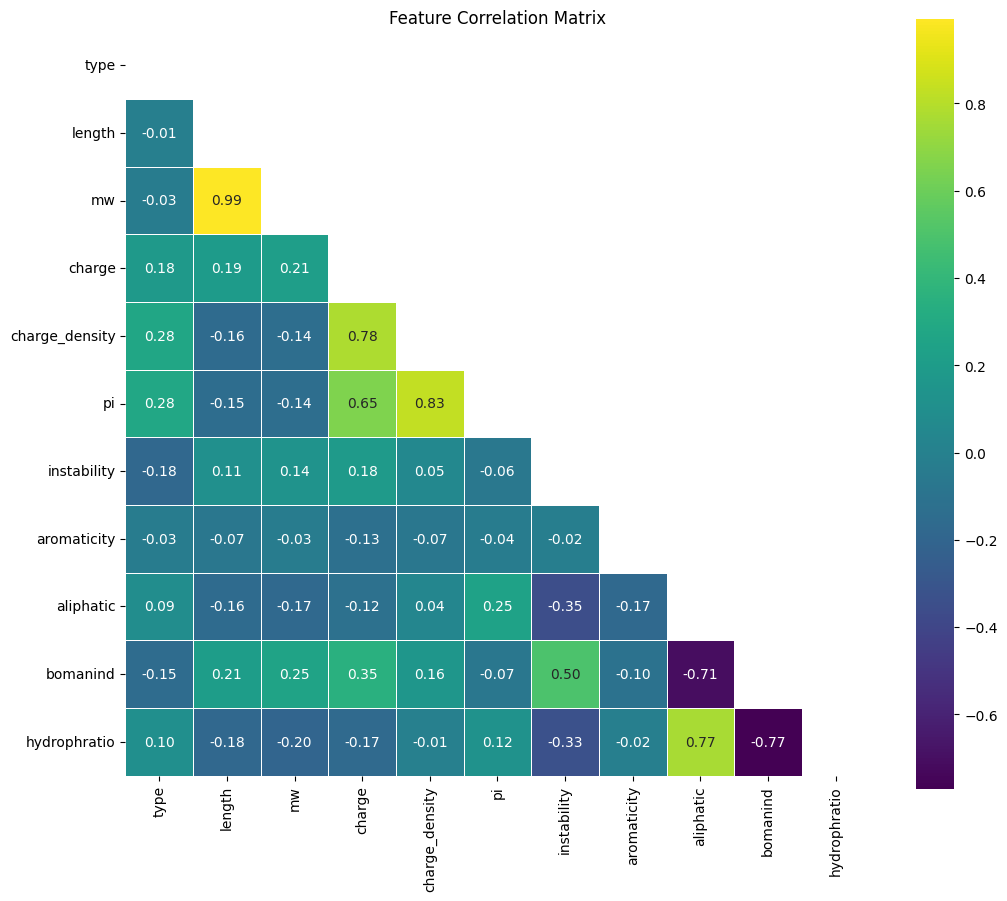

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df_numeric = df.drop(columns=['id', 'sequence']).apply(pd.to_numeric)
corr_matrix = df_numeric.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    cmap='viridis', 
    annot=True, 
    fmt=".2f", 
    square=True, 
    linewidths=.5
)
plt.title('Feature Correlation Matrix')
plt.show()

Podemos observar alta correlación entre variables como longitud de la secuencia y el peso molecular (0.99), la densidad de la carga y la carga (0.78), el punto isoeléctrico y la densidad de carga (0.83), y su es alifatico o hidrofobico (0.77).
Por otro lado, las correlaciones inversas más altas son entre el índice de Boman y si es alifatico (-0.71), y el índice de Boman y la hidrofobicidad (-0.77).

### **Normalidad**

In [19]:
# Se le hace un test de normalidad a cada variable

import pandas as pd
from scipy import stats

numeric_cols = df.drop(columns=['id', 'sequence', 'type']).apply(pd.to_numeric)

results = []
for col in numeric_cols.columns:
    stat, p_value = stats.shapiro(numeric_cols[col].dropna())
    results.append({
        'Feature': col,
        'Statistic': stat,
        'p-value': p_value,
        'Is_Normal': p_value > 0.05
    })

normality_results = pd.DataFrame(results)
print(normality_results)

          Feature  Statistic       p-value  Is_Normal
0          length   0.761690  5.390253e-71      False
1              mw   0.763996  8.526360e-71      False
2          charge   0.895538  4.001791e-55      False
3  charge_density   0.978346  1.482469e-30      False
4              pi   0.952044  4.935569e-42      False
5     instability   0.872283  8.403256e-59      False
6     aromaticity   0.930245  4.185107e-48      False
7       aliphatic   0.984758  4.284664e-26      False
8        bomanind   0.975420  2.943541e-32      False
9    hydrophratio   0.995400  1.146088e-13      False


c:\Users\Jazmin\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 6612.
  res = hypotest_fun_out(*samples, **kwds)


Como se rechaza la hipotesis de que las variables tienen distribución normal, se descarta el uso del modelo Gaussian Naive Bayes.

### **Información mutua**

Se calculó la información mutua de las variables, con la fórmula:
$$H(X, Y) = \sum_{X} \sum_{Y} P(X, Y) \log_2 \left[ P(X, Y) / P(X)P(Y) \right]$$

**Es cero cuando dos variables son independientes**

In [22]:
import numpy as np
import pandas as pd

def calculate_mi(x, y, bins=10):
    c_xy, _, _ = np.histogram2d(x, y, bins=bins)
    p_xy = c_xy / np.sum(c_xy)
    
    p_x = np.sum(p_xy, axis=1)
    p_y = np.sum(p_xy, axis=0)
    p_x_p_y = p_x[:, None] * p_y[None, :]
    
    mask = p_xy > 0
    return np.sum(p_xy[mask] * np.log2(p_xy[mask] / p_x_p_y[mask]))

df_numeric = df.drop(columns=['id', 'sequence']).apply(pd.to_numeric)
mutual_information = pd.DataFrame(index=df_numeric.columns, columns=df_numeric.columns, dtype=float)

for col1 in df_numeric.columns:
    for col2 in df_numeric.columns:
        mutual_information.loc[col1, col2] = calculate_mi(df_numeric[col1], df_numeric[col2])

In [23]:
mutual_information

,type,length,mw,charge,charge_density,pi,instability,aromaticity,aliphatic,bomanind,hydrophratio
type,1.000000,0.000297,0.000926,0.085854,0.112713,0.075967,0.024428,0.002458,0.009304,0.018417,0.011449
length,0.000297,2.057701,1.484746,0.081537,0.057497,0.115877,0.056060,0.038839,0.127167,0.112729,0.127361
mw,0.000926,1.484746,2.014009,0.097420,0.047446,0.116478,0.065644,0.032328,0.135059,0.130639,0.127928
charge,0.085854,0.081537,0.097420,1.240698,0.530129,0.713056,0.072617,0.024686,0.070649,0.148455,0.082637
charge_density,0.112713,0.057497,0.047446,0.530129,1.807256,0.754639,0.073468,0.024025,0.047686,0.145214,0.060441
pi,0.075967,0.115877,0.116478,0.713056,0.754639,3.017964,0.066807,0.031822,0.164826,0.157919,0.082642
instability,0.024428,0.056060,0.065644,0.072617,0.073468,0.066807,1.642443,0.015346,0.103549,0.155564,0.107966
aromaticity,0.002458,0.038839,0.032328,0.024686,0.024025,0.031822,0.015346,1.904495,0.036678,0.024637,0.036560
aliphatic,0.009304,0.127167,0.135059,0.070649,0.047686,0.164826,0.103549,0.036678,2.614065,0.521186,0.629987
bomanind,0.018417,0.112729,0.130639,0.148455,0.145214,0.157919,0.155564,0.024637,0.521186,2.101734,0.628186


### **Transformación de variables** 



Con base en el análisis de correlación, se identificaron **tres grupos con alta dependencia condicional** que violan el supuesto de independencia del NBC. Siguiendo el enfoque SNBC, cuando dos atributos no son independientes dado la clase, se debe **eliminar uno o fusionarlos**.

1.1 Eliminación: `length` 

Debido a que `length` y `mw` tienen correlación de **r = 0.99**, se decidió eliminar length.

1.2 Fusión: `charge`, `charge_density` y `pi`

Correlaciones altas entre sí (r entre 0.78 y 0.83). Las tres tienen información mutua >0 con la actividad microbiana (type) (MI = 0.085, 0.112 y 0.075), por lo que no se elimina ninguna. **Se fusionan en `charge_pi_density`** (media de sus z-scores).

1.3 Fusión: `aliphatic`, `bomanind` y `hydrophratio`

Correlaciones cruzadas de |r| entre 0.71 y 0.77 dentro de cada clase. Describen propiedades relacionadas con hidrofobicidad y estabilidad. **Se fusionan en `hydrophobic_profile`** (media de sus z-scores).

Los atributos `instability` y `aromaticity` **permanecen sin cambios**.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_classif
import warnings
warnings.filterwarnings("ignore")

# Paso 1: Eliminar length 
df_clean = df.drop(columns=["length"])

# Paso 2: Fusionar charge + charge_density + pi
for col in ["charge", "charge_density", "pi"]:
    df_clean[col + "_z"] = (df_clean[col] - df_clean[col].mean()) / df_clean[col].std()

df_clean["charge_pi_density"] = (
    df_clean["charge_z"] + df_clean["charge_density_z"] + df_clean["pi_z"]
) / 3

df_clean = df_clean.drop(columns=[
    "charge", "charge_density", "pi",
    "charge_z", "charge_density_z", "pi_z"
])

# Paso 3: Fusionar aliphatic + bomanind + hydrophratio
for col in ["aliphatic", "bomanind", "hydrophratio"]:
    df_clean[col + "_z"] = (df_clean[col] - df_clean[col].mean()) / df_clean[col].std()

df_clean["hydrophobic_profile"] = (
    df_clean["aliphatic_z"] + df_clean["bomanind_z"] + df_clean["hydrophratio_z"]
) / 3

df_clean = df_clean.drop(columns=[
    "aliphatic", "bomanind", "hydrophratio",
    "aliphatic_z", "bomanind_z", "hydrophratio_z"
])

print("Variables finales:", list(df_clean.columns))
df_clean.head(3)

## **Representación del modelo**
Este ejercicio tiene por objetivo realizar una clasificación binaria de los péptidos, en si son antimicrobianos o si no lo son. Por lo tanto, los modelos Dinámicos y Temporales, de Clasificación Jerárquica y Multidimensionales y Multietiqueta quedan descartados.
Para nuestro próposito podrían servirnos los siguientes:
- Clasificador Bayesiano Ingenuo (NBC): El cual asume independencia condicional entre todos los atributos dada la clase
- Gaussian Naive Bayes: Los atributos siguen una distribución gaussiana
- TAN (Tree Augmented Bayesian Classifier): Incorpora dependencias entre atributos formando una estructura de árbol dirigido entre ellos
- BAN (Bayesian Network augmented Bayesian Classifier): Relaja la restricción de árbol del TAN, permitiendo que los atributos formen un grafo acíclico dirigido (DAG)
- Clasificadores Bayesianos Semi-ingenuos (SNBC): Buscan mejorar el NBC eliminando atributos irrelevantes o uniendo atributos dependientes para mantener la eficiencia

Para empezar a ver cuál modelo podría servirnos, vamos a ver si hay correlación entre las variables y cómo se distribuyen.